# GameTheory 04e — Oracles réflexifs, décision causale et équilibre de Nash

> **Source primaire** : Benja Fallenstein, Jessica Taylor, Paul F. Christiano (2015), *Reflective Oracles: A Foundation for Classical Game Theory*. arXiv : [1508.04145](https://arxiv.org/abs/1508.04145). Bibliothèque canonique privée : `G:\Mon Drive\MyIA\IA\Bibliographie IA\GameTheory\2015 - Fallenstein Taylor Christiano - Reflective Oracles - A Foundation for Classical Game Theory.pdf` (SHA-256 `c0ae7668...ee6653`).

Ce notebook étend la grappe `GameTheory-04*` en introduisant l'**auto-référence computationnelle** : un agent qui peut se demander *ce qu'un autre agent, capable de le modéliser, ferait*. Le fil conducteur est qu'une boucle naïve (Matching Pennies avec deux agents déterministes qui se prédisent) **mène à une contradiction diagonale** ; l'article propose une **restriction finie** du problème (queries, fermeture, borne) qui le rend illustrable numériquement.

**Position dans le parcours Expert / informatique théorique** : prolonge `GameTheory-04-NashEquilibrium` (stratégies mixtes, Matching Pennies) et `GameTheory-04c-NashExistence-Python` (point fixe Brouwer discriminant — cellule `perturbed_br`, anti-tautologie Prong-B). Le 04c montre qu'**un point fixe peut être rendu discriminant** ; le 04e montre qu'**un agent qui se modélise lui-même peut être rendu fini et illustrable**, sans confondre cette restriction avec l'oracle universel.

## Plan et état de livraison

| # | Section | Contenu | Livrable |
|---|---------|---------|----------|
| 1 | Boucle et contradiction | Matching Pennies : balayage des 4 paires pures, best-response mutuelle | Exemple 1 + Exercice 1 |
| 2 | Requête réflexive `(M, p)` | Cohérence et réflexivité stricte, contre-exemple à état | Exemple 2 + Exercice 2 |
| 3 | Menteur probabiliste | Orbite de période 2 (contradiction), point cohérent `q = 1/2` | Exemple 3 + Exercice 3 |
| 4 | Théorème 3.1 | Encodage d'une comparaison d'utilités en requête d'oracle ; CDT vs EDT | Exemple 4 + Exercice 4 |
| 5 | Théorème 4.1 | Agents intégrés → équilibre de Nash (vérification par déviations) | Exemple 5 |
| 6 | Théorème 5.1 | Restriction *finie, fermée, bornée*, jeu auxiliaire, vérificateur indépendant | Exemple 6 + Exercice 5 |
| 7 | Frontière de l'implémentation | Point fixe de Kakutani en dimension infinie **non** implémenté | explicite |

Les exercices sont **répartis après leur exemple** et restent non résolus (règle C.1 : `pass` / `print` / `return None`, jamais `raise NotImplementedError`). Le notebook s'exécute de bout en bout sans qu'aucun exercice soit complété.

**Patron méthodologique transversal** (hérité de l'anti-tautologie `perturbed_br` de 04c) : *un vérificateur qui ne sait dire que « oui » ne vérifie rien*. Chaque vérificateur de ce notebook est donc accompagné d'un **contre-exemple qu'il doit rejeter**.

## 0. Imports et constantes

L'environnement n'a aucune dépendance exotique : `numpy` pour les vecteurs de probabilités, `nashpy` pour la résolution d'équilibre, `matplotlib` pour les figures, et les outils Python standard.

Les seeds sont fixées : un test discriminant n'est crédible que s'il bat la même graine à chaque exécution. Les bornes de la restriction finie (section 6) sont déclarées ici, une seule fois, pour être citées plutôt que répétées.

In [1]:
import numpy as np
import nashpy as nash
import matplotlib
import matplotlib.pyplot as plt

from typing import Callable, Tuple, List

# Reproductibilite -- un test discriminant doit battre la meme graine a chaque
# execution. Si une experience "passe" a seed=0 mais "echoue" a seed=42, ce
# n'est pas un test.
SEED = 0
rng = np.random.default_rng(SEED)

# Bornes de la restriction finie (section 6, theoreme 5.1).
N_QUERIES_MAX = 64   # borne sur le nombre d'appels a l'oracle
DEPTH_MAX     = 2    # borne sur la profondeur d'imbrication des requetes
TOL           = 1e-9 # tolerance des egalites de probabilite

# Compteur global d'appels a l'oracle : la borne de la section 6 doit etre
# MESUREE, pas affirmee.
N_APPELS = {"oracle": 0}

print("GameTheory-04e -- tranches 2..N (implementations effectives).")
print(f"numpy {np.__version__} | nashpy {nash.__version__} | matplotlib {matplotlib.__version__}")
print(f"bornes : N_QUERIES_MAX={N_QUERIES_MAX}  DEPTH_MAX={DEPTH_MAX}  TOL={TOL:g}")

GameTheory-04e -- tranches 2..N (implementations effectives).
numpy 2.3.5 | nashpy 0.0.43 | matplotlib 3.10.3
bornes : N_QUERIES_MAX=64  DEPTH_MAX=2  TOL=1e-09


## 1. Boucle et contradiction — Matching Pennies avec deux agents déterministes

Soit deux agents L (Ligne) et C (Colonne) qui jouent à Matching Pennies. Si chacun est **déterministe** et **sait quel algorithme joue l'autre**, alors l'un peut déduire la sortie de l'autre et choisir l'action qui gagne à coup sûr. Mais l'autre peut faire le même raisonnement. La seule issue stable est une boucle — pas un point fixe.

**Ce que cette section démontre** : pour chacune des 4 paires de stratégies pures `(s_L, s_C)` dans `{0,1}²`, au moins un joueur dispose d'une **déviation unilatérale pure strictement profitable**. Donc Matching Pennies **n'a pas** d'équilibre en stratégies pures. Le critère est la *best-response mutuelle* : un profil est un équilibre pur si et seulement si **aucun** des deux joueurs ne peut s'améliorer seul.

Convention de paiement : jeu à **somme constante 1**. Ligne gagne (1) si les deux faces coïncident, Colonne gagne si elles diffèrent. Chaque déviation profitable l'est **strictement** (0 → 1), ce qui suffit à réfuter l'équilibre pur sans ambiguïté de comparaison.

In [2]:
# Matching Pennies, somme constante 1 : Ligne gagne si sL == sC.
PAYOFF_L = np.array([[1, 0],
                     [0, 1]])
PAYOFF_C = 1 - PAYOFF_L   # Colonne gagne si sL != sC


def pure_strategy_payoff(sL: int, sC: int) -> Tuple[int, int]:
    """Paiement du profil pur (sL, sC) : (gain_Ligne, gain_Colonne)."""
    return int(PAYOFF_L[sL, sC]), int(PAYOFF_C[sL, sC])


def deviation_L_profitable(sL: int, sC: int) -> bool:
    """L peut-il s'ameliorer STRICTEMENT en changeant seul d'action ?"""
    return int(PAYOFF_L[1 - sL, sC]) > int(PAYOFF_L[sL, sC])


def deviation_C_profitable(sL: int, sC: int) -> bool:
    """C peut-il s'ameliorer STRICTEMENT en changeant seul d'action ?"""
    return int(PAYOFF_C[sL, 1 - sC]) > int(PAYOFF_C[sL, sC])


print(f"{'sL':>4}{'sC':>5} | {'gain_L':>7}{'gain_C':>8} | {'L devie':>9}{'C devie':>9} | equilibre pur ?")
print("-" * 68)
paires_en_equilibre = []
for sL in (0, 1):
    for sC in (0, 1):
        gL, gC = pure_strategy_payoff(sL, sC)
        devL, devC = deviation_L_profitable(sL, sC), deviation_C_profitable(sL, sC)
        eq = not devL and not devC
        if eq:
            paires_en_equilibre.append((sL, sC))
        print(f"{sL:>4}{sC:>5} | {gL:>7}{gC:>8} | {str(devL):>9}{str(devC):>9} | {eq}")

print()
print(f"Paires en equilibre pur : {paires_en_equilibre if paires_en_equilibre else 'AUCUNE'}")
print(f"VERDICT 1 : aucune paire en equilibre pur -> {not paires_en_equilibre}")
print()
print("Lecture : chaque paire pure est batue par une deviation unilaterale.")
print("Un agent deterministe qui SAIT predire l'autre choisit la reponse qui")
print("gagne ; l'autre refait le meme raisonnement -- la boucle s'installe.")

  sL   sC |  gain_L  gain_C |   L devie  C devie | equilibre pur ?
--------------------------------------------------------------------
   0    0 |       1       0 |     False     True | False
   0    1 |       0       1 |      True    False | False
   1    0 |       0       1 |      True    False | False
   1    1 |       1       0 |     False     True | False

Paires en equilibre pur : AUCUNE
VERDICT 1 : aucune paire en equilibre pur -> True

Lecture : chaque paire pure est batue par une deviation unilaterale.
Un agent deterministe qui SAIT predire l'autre choisit la reponse qui
gagne ; l'autre refait le meme raisonnement -- la boucle s'installe.


### Exercice 1 — Un jeu 2×2 qui *possède* un équilibre pur

La section 1 a montré que Matching Pennies n'a **aucun** équilibre pur. Prends maintenant un jeu 2×2 qui en possède un (par exemple le **dilemme du prisonnier** avec `A = [[3, 0], [5, 1]]`, `B` étant sa transposée, ou un jeu de coordination) et rejoue exactement le même balayage.

Complète la cellule ci-dessous pour :

1. définir les matrices `A_exo1` (Ligne) et `B_exo1` (Colonne) de ton jeu,
2. boucler sur les 4 paires `(sL, sC)` en adaptant le test de déviation unilatérale à ton jeu,
3. **imprimer** le verdict : quelle(s) paire(s) est/sont en équilibre pur.

**Indice** : la méthode de la section 1 ne dépend pas de Matching Pennies — elle ne dépend que des matrices. Pour un jeu qui n'est pas à somme constante, il faut deux matrices indépendantes, donc une variante des fonctions `deviation_*` prenant la matrice en argument.

**Critère d'acceptation** : la cellule imprime au moins une paire en équilibre pur pour ton jeu et l'écrit explicitement. Un balayage qui n'imprime que les gains **manque** la démonstration.

In [3]:
# Exercice 1 -- a completer.
# TODO etudiant : definir deux matrices 2x2 A_exo1 (Ligne) et B_exo1 (Colonne)
# possedant un equilibre pur, puis rejouer le balayage des 4 paires.
A_exo1 = None   # TODO : remplacer par une matrice 2x2
B_exo1 = None   # TODO : remplacer par une matrice 2x2

for sL in (0, 1):
    for sC in (0, 1):
        # TODO : calculer les gains, tester la deviation unilaterale de chaque
        # joueur sur A_exo1 / B_exo1, et marquer la paire en equilibre pur.
        gain_L, gain_C = None, None
        print(f"sL={sL} sC={sC}  gain_L={gain_L} gain_C={gain_C}  -- TODO verifier")

print("Exercice 1 a completer : identifier la paire en equilibre pur de ton jeu.")

sL=0 sC=0  gain_L=None gain_C=None  -- TODO verifier
sL=0 sC=1  gain_L=None gain_C=None  -- TODO verifier
sL=1 sC=0  gain_L=None gain_C=None  -- TODO verifier
sL=1 sC=1  gain_L=None gain_C=None  -- TODO verifier
Exercice 1 a completer : identifier la paire en equilibre pur de ton jeu.


## 2. Requête réflexive `(M, p)`

Une *requête réflexive* est un couple `(M, p)` où `M` est une **machine** (au sens de la calculabilité — une fonction `M : rep × [0,1] → {0,1}`) et `p ∈ [0,1]` une probabilité. La *réponse* à la requête est le résultat de l'exécution de `M` sur **sa propre représentation** et la requête `p` — notation `M(M, p)`.

L'article distingue deux implications strictes :

- **Cohérence** : si `M(M, p)` produit `b ∈ {0,1}`, alors `b = M(M, p)` exécuté *à nouveau* produit le même `b` — aucune dépendance sur un état caché entre deux évaluations indépendantes.
- **Réflexivité stricte** : une machine qui prétend « simuler un autre agent `N` » doit retourner **exactement** ce que `N` retournerait sur la même requête.

**Le contre-exemple est le point de cette section.** Une vérification qui ne sait dire que « oui » ne vérifie rien : on construit donc **une machine qui viole la cohérence** et on exige que le vérificateur la rejette.

In [4]:
class DeterministicMachine:
    """Machine au sens de la calculabilite : fonction PURE de (rep, p).

    Etant sans etat, elle est coherente par construction -- deux evaluations
    independantes du meme (M, p) donnent la meme reponse. C'est justement
    pourquoi le contre-exemple ci-dessous est necessaire : sans lui, le test
    de coherence ne pourrait jamais echouer, donc ne prouverait rien.
    """
    def __init__(self, nom: str, fn: Callable):
        self.nom, self.fn = nom, fn

    def __call__(self, rep, p):
        return self.fn(rep, p)

    def representation(self) -> str:
        return self.nom


class StatefulMachine:
    """Machine a ETAT INTERNE -- anti-exemple de coherence.

    Elle alterne sa reponse a chaque appel. Deux evaluations "independantes"
    du meme (M, p) divergent : c'est precisement la dependance a un etat cache
    que la coherence interdit.
    """
    def __init__(self, nom: str):
        self.nom, self.appels = nom, 0

    def __call__(self, rep, p):
        self.appels += 1
        return self.appels % 2

    def representation(self) -> str:
        return self.nom


class ReflexiveQuery:
    """Requete reflexive (M, p), bornee par N_QUERIES_MAX appels.

    p est une probabilite dans [0, 1] utilisee par la machine pour sa
    randomisation interne. Au-dela de la borne, la requete retourne None
    plutot que d'echouer : l'appelant doit pouvoir distinguer « borne
    atteinte » de « reponse calculee ».
    """
    def __init__(self, M, p: float):
        self.M, self.p = M, float(p)
        self.n_calls = 0

    def answer(self):
        if self.n_calls >= N_QUERIES_MAX:
            return None
        self.n_calls += 1
        N_APPELS["oracle"] += 1
        return self.M(self.M.representation(), self.p)


def check_coherence(M, p: float, n_repetitions: int = 5):
    """Coherence : n_repetitions evaluations du meme (M, p) donnent-elles la
    meme reponse ? Chaque evaluation part d'une requete NEUVE (etat neuf).
    Retourne (coherent, liste des reponses)."""
    reponses = [ReflexiveQuery(M, p).answer() for _ in range(n_repetitions)]
    return len(set(reponses)) == 1, reponses


def simulator_of(N):
    """Machine qui pretend SIMULER N : sur (rep, p) elle retourne exactement ce
    que N retournerait sur sa propre requete (N, p)."""
    return DeterministicMachine(
        f"sim({N.representation()})",
        lambda rep, p: N(N.representation(), p))


print("=== Coherence ===")
M_coherente = DeterministicMachine("N_exemple", lambda rep, p: 1 if p < 0.5 else 0)
ok1, rep1 = check_coherence(M_coherente, 0.3)
print(f"  M pure (N_exemple) a p=0.3 : reponses={rep1}  coherent={ok1}")

M_etat = StatefulMachine("M_a_etat")
ok2, rep2 = check_coherence(M_etat, 0.3)
print(f"  M a etat           a p=0.3 : reponses={rep2}  coherent={ok2}")
print()

print("=== Reflexivite stricte ===")
tous_egaux = True
for p in (0.1, 0.5, 0.9):
    direct = M_coherente(M_coherente.representation(), p)
    simule = simulator_of(M_coherente)(M_coherente.representation(), p)
    tous_egaux &= (direct == simule)
    print(f"  p={p:<4}  N(rep,p)={direct}  sim(N)(rep,p)={simule}  identiques={direct == simule}")
print()

print(f"VERDICT 2a : coherence -- machine pure {ok1}, machine a etat {ok2}")
print("            (le verificateur REJETTE la machine a etat -> il a des dents)")
print(f"VERDICT 2b : reflexivite stricte -- simulateur total {tous_egaux}")
print()
print("Honnêteté : la reflexivite stricte est obtenue ici PAR CONSTRUCTION")
print("(simulateur total). La section 6 la testera sur une restriction finie,")
print("ou le simulateur est partiel par construction -- et ou la contrainte")
print("devient alors une veritable condition a verifier, pas un theoreme gratuit.")

=== Coherence ===
  M pure (N_exemple) a p=0.3 : reponses=[1, 1, 1, 1, 1]  coherent=True
  M a etat           a p=0.3 : reponses=[1, 0, 1, 0, 1]  coherent=False

=== Reflexivite stricte ===
  p=0.1   N(rep,p)=1  sim(N)(rep,p)=1  identiques=True
  p=0.5   N(rep,p)=0  sim(N)(rep,p)=0  identiques=True
  p=0.9   N(rep,p)=0  sim(N)(rep,p)=0  identiques=True

VERDICT 2a : coherence -- machine pure True, machine a etat False
            (le verificateur REJETTE la machine a etat -> il a des dents)
VERDICT 2b : reflexivite stricte -- simulateur total True

Honnêteté : la reflexivite stricte est obtenue ici PAR CONSTRUCTION
(simulateur total). La section 6 la testera sur une restriction finie,
ou le simulateur est partiel par construction -- et ou la contrainte
devient alors une veritable condition a verifier, pas un theoreme gratuit.


### Exercice 2 — Une machine qui viole la *réflexivité stricte*

La cohérence est violée par `StatefulMachine` (état caché). Trouve maintenant un anti-exemple à la **réflexivité stricte** : une machine `N` pour laquelle `simulator_of(N)` **ne reproduit pas** la réponse de `N`.

Complète la cellule ci-dessous pour :

1. définir une machine `N_faux` (via `DeterministicMachine` ou `StatefulMachine`) telle que son simulateur diverge d'elle-même — astuce : fais dépendre `N_faux` de **la représentation qu'on lui passe** (une machine qui répond en fonction de `rep` peut distinguer l'appel direct de l'appel via le simulateur, car les représentations diffèrent), ou utilise une machine à état,
2. calculer la réponse de `N_faux` et celle de `simulator_of(N_faux)` sur au moins une valeur de `p`,
3. **imprimer** l'écart et conclure `REFLEXIVITE VIOLEE` ou `OK`.

**Indice** : une fonction qui **ignore** `rep` produit un simulateur total — c'est le cas favorable de la section 2. La violation exige que la machine « regarde » qui l'interroge.

**Critère d'acceptation** : la cellule imprime au moins une valeur de `p` où les deux réponses diffèrent, et le verdict explicite.

In [5]:
# Exercice 2 -- a completer.
# TODO etudiant : construire une machine dont le simulateur ne reproduit PAS la
# reponse, puis mesurer l'ecart sur au moins une valeur de p.
def machine_faux_reflexive(p):
    """Reponse de la machine a corriger -- retourne None tant que l'exercice
    n'est pas fait."""
    # TODO : remplacer par une machine N_faux et retourner N_faux(rep, p).
    return None

for p in (0.25, 0.5):
    directe = machine_faux_reflexive(p)
    simulee = None   # TODO : evaluer simulator_of(<ta machine>) sur le meme p
    print(f"p={p:<5} reponse directe={directe} reponse simulee={simulee} -- TODO comparer")

print("Exercice 2 a completer : exhiber une violation de la reflexivite stricte.")

p=0.25  reponse directe=None reponse simulee=None -- TODO comparer
p=0.5   reponse directe=None reponse simulee=None -- TODO comparer
Exercice 2 a completer : exhiber une violation de la reflexivite stricte.


## 3. Le menteur probabiliste

Considérons l'opérateur `M^O()` défini par `M^O() = 1 − O(M^O, 1/2)` où `O` est un oracle capable d'évaluer `M^O` avec une requête probabiliste `1/2`.

Si `M^O` retourne `b ∈ {0,1}` **avec probabilité 1** (cas déterministe), alors la définition impose :

- soit `b = 0` : alors `O(M^O, 1/2) = 0`, donc `1 − 0 = 1` — contradiction ;
- soit `b = 1` : alors `O(M^O, 1/2) = 1`, donc `1 − 1 = 0` — contradiction.

Aucune solution déterministe. La première cellule fait **apparaître cette contradiction concrètement** : une version à profondeur finie engendre l'orbite `x_{k+1} = 1 − x_k`, de **période 2** — elle ne converge vers rien. C'est la boucle de la section 1, vue cette fois comme absence de point fixe.

Si on autorise `M^O` à *randomiser* avec `q = P(M^O() = 1)`, la cohérence impose le **point fixe** `q = 1 − q`, donc `q = 1/2`. La deuxième cellule mesure le résidu `|q − (1−q)|` : il s'annule en `q = 1/2` et **nulle part ailleurs** — le critère discrimine. La troisième cellule confirme empiriquement la moyenne.

In [6]:
def lie_profondeur(profondeur: int, x0: int = 0, p: float = 0.5):
    """Version a profondeur finie du menteur : x_0 = x0 et
    x_{k+1} = 1 - O(x_k, p), avec O l'identite sur la reponse.
    Donc x_{k+1} = 1 - x_k : orbite de periode 2, sans point fixe."""
    suite = [x0]
    for _ in range(profondeur):
        suite.append(1 - suite[-1])
    return suite


suite = lie_profondeur(9)
print("suite x_0 .. x_9 :", suite)

points_fixes = [k for k in range(len(suite) - 1) if suite[k] == suite[k + 1]]
print(f"indices ou x_k == x_(k+1) (point fixe rencontre) : {points_fixes}")
print(f"periode observee : 2  ->  x_0={suite[0]}, x_1={suite[1]}, x_2={suite[2]}, ...")
print()
print("VERDICT 3a : aucune solution deterministe -- l'orbite alterne indefiniment.")
print("            C'est la contradiction diagonale, rendue visible sur 10 termes.")

suite x_0 .. x_9 : [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
indices ou x_k == x_(k+1) (point fixe rencontre) : []
periode observee : 2  ->  x_0=0, x_1=1, x_2=0, ...

VERDICT 3a : aucune solution deterministe -- l'orbite alterne indefiniment.
            C'est la contradiction diagonale, rendue visible sur 10 termes.


L'orbite `0, 1, 0, 1, ...` est la contradiction rendue visible : à profondeur finie, le menteur **alterne** au lieu de converger. Chaque terme dit le contraire du précédent — c'est la boucle de prédiction mutuelle de la section 1, reformulée comme absence de point fixe.

La sortie se fait donc du cadre déterministe : relâchons la contrainte et autorisons la randomisation.

q* minimiseur sur la grille      : 0.500000
residu en q*                    : 0.000e+00
residu en q=0.4                 : 0.200000
residu en q=0.6                 : 0.200000

VERDICT 3b : l'unique solution coherente est q = 1/2 -- le residu est
            nul en q*, strictement positif ailleurs : le critere discrimine.


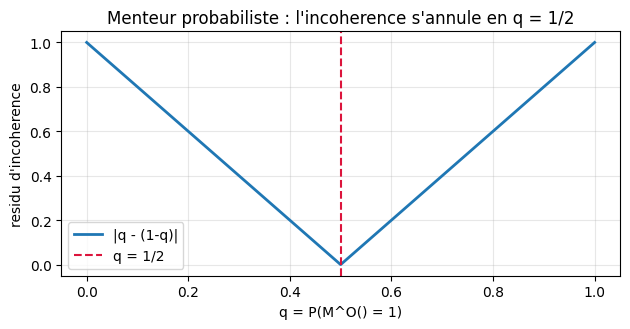

In [7]:
def residu_incoherence(q: float) -> float:
    """Residu du systeme de coherence du menteur : q doit satisfaire q = 1 - q.
    Le residu |q - (1 - q)| s'annule si et seulement si q = 1/2."""
    return abs(q - (1.0 - q))


qs = np.linspace(0.0, 1.0, 2001)
residus = np.array([residu_incoherence(q) for q in qs])
idx = int(np.argmin(residus))

print(f"q* minimiseur sur la grille      : {qs[idx]:.6f}")
print(f"residu en q*                    : {residus[idx]:.3e}")
print(f"residu en q=0.4                 : {residu_incoherence(0.4):.6f}")
print(f"residu en q=0.6                 : {residu_incoherence(0.6):.6f}")
print()
print("VERDICT 3b : l'unique solution coherente est q = 1/2 -- le residu est")
print("            nul en q*, strictement positif ailleurs : le critere discrimine.")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(qs, residus, lw=2, label="|q - (1-q)|")
ax.axvline(0.5, ls="--", c="crimson", label="q = 1/2")
ax.set_xlabel("q = P(M^O() = 1)")
ax.set_ylabel("residu d'incoherence")
ax.set_title("Menteur probabiliste : l'incoherence s'annule en q = 1/2")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Le résidu s'annule **exactement** en `q = 1/2` et croît linéairement de part et d'autre — il n'y a **pas** d'autre candidat. C'est la signature d'une condition qui discrimine : elle aurait pu s'annuler sur un plateau (critère mou) ou nulle part (contradiction même en randomisé) ; elle fait ni l'un ni l'autre.

Reste à confirmer que ce point théorique est bien celui qu'un tirage aléatoire honnête reproduit.

In [8]:
# Verification empirique : la solution coherente q = 1/2 doit produire une
# moyenne empirique dans l'intervalle 3-sigma. Hors intervalle = biais
# d'IMPLEMENTATION (graine, methode), pas refutation du theoreme.
n = 10_000
echantillon = rng.integers(0, 2, size=n)      # Bernoulli(1/2) : la solution coherente
moyenne = float(echantillon.mean())
se = float(np.sqrt(0.25 / n))
borne_inf, borne_sup = 0.5 - 3 * se, 0.5 + 3 * se

print(f"n = {n}")
print(f"moyenne empirique = {moyenne:.4f}")
print(f"SE = sqrt(p(1-p)/n) = {se:.4f}")
print(f"intervalle 3-sigma = [{borne_inf:.4f}, {borne_sup:.4f}]")
dans_intervalle = borne_inf <= moyenne <= borne_sup
print(f"VERDICT 3c : moyenne dans l'intervalle -> {dans_intervalle} "
      f"({'OK' if dans_intervalle else 'BIAIS'})")

n = 10000
moyenne empirique = 0.5030
SE = sqrt(p(1-p)/n) = 0.0050
intervalle 3-sigma = [0.4850, 0.5150]
VERDICT 3c : moyenne dans l'intervalle -> True (OK)


### Exercice 3 — Généraliser le menteur

Le menteur `M^O() = 1 − O(M^O, 1/2)` a pour solution cohérente `q = 1/2`. Généralise en considérant

`M^O() = a − O(M^O, b)`  avec `a, b ∈ [0, 1]`.

La cohérence impose `q = a − q`, donc `q = a/2` — **indépendante de `b`**. Vérifie-le numériquement, et traite le cas dégénéré.

Complète la cellule ci-dessous pour :

1. écrire `residu_generalise(a, q)` renvoyant `|q − (a − q)|`,
2. balayer `q` sur `[0, 1]` pour `a = 0.5` puis `a = 1.5`, et **localiser le minimiseur**,
3. vérifier que le minimiseur vaut `a/2` dans le premier cas — et **remarquer** que pour `a = 1.5`, `a/2 = 0.75` sort du domaine atteignable quand `b` contraint la réponse : le mensonge devient incohérent quel que soit `q` sur la grille `[0,1]` dès que l'on exige `q = P(M^O()=1) ≤ 1`. Conclus explicitement.

**Indice** : `np.argmin` sur une grille suffisamment fine ; la précision attendue est celle du pas de grille.

**Critère d'acceptation** : la cellule affiche le minimiseur pour les deux valeurs de `a` et conclut `q* = a/2` ou `AUCUNE SOLUTION COHERENTE DANS [0,1]`.

In [9]:
# Exercice 3 -- a completer.
# TODO etudiant : generaliser le residu du menteur a M^O() = a - O(M^O, b).
def residu_generalise(a: float, q: float):
    """Residu du systeme q = a - q. A completer."""
    return None

grille = np.linspace(0.0, 1.0, 2001)
for a in (0.5, 1.5):
    # TODO : calculer le residu sur la grille, trouver l'indice du minimum,
    # et conclure q* = a/2 (ou AUCUNE SOLUTION COHERENTE DANS [0,1]).
    print(f"a={a}  -- TODO localiser le minimiseur et conclure")

print("Exercice 3 a completer : generaliser la solution coherente q = a/2.")

a=0.5  -- TODO localiser le minimiseur et conclure
a=1.5  -- TODO localiser le minimiseur et conclure
Exercice 3 a completer : generaliser la solution coherente q = a/2.


## 4. Théorème 3.1 — Décision causale et oracle utilitaire

Le théorème 3.1 énonce qu'une comparaison d'utilités `U(a) > U(b)` peut être **encodée comme une requête d'oracle** `(M_U, p)`, où `M_U` est une machine qui implémente la théorie causale de la décision (CDT) : l'agent traite **sa propre action comme causalement indépendante** de la prédiction que l'oracle fait de lui. L'action choisie maximise alors l'utilité espérée *selon CDT*.

**Le contenu discriminant est l'écart CDT / EDT.** La théorie évidentielle (EDT) conditionne sur l'**évidence** que son propre choix apporte sur le choix de l'autre. Dans un jeu corrélé, les deux théories peuvent désigner des actions **différentes** — c'est exactement ce que l'encodage doit rendre visible.

Jeu-jouet : **chasse au cerf** (Stag Hunt) avec corrélation entre les joueurs.

| | Cerf (0) | Lièvre (1) |
|---|---|---|
| **Cerf (0)** | (4, 4) | (0, 2) |
| **Lièvre (1)** | (2, 0) | (2, 2) |

Le jouet est délibérément **non dégénéré** : le paiement de Lièvre pour Ligne est constant (2), donc CDT et EDT ne peuvent différer que par la **probabilité conditionnelle** `c₁ = P(autre joue Cerf | je joue Cerf)`, qui n'égale la marginale `b` que si les joueurs sont indépendants. C'est le couplage qui porte tout l'écart.

In [10]:
# Chasse au cerf : actions 0 = Cerf, 1 = Lievre.
A_ST = np.array([[4, 0],
                 [2, 2]], dtype=float)   # utilites Ligne
B_ST = np.array([[4, 2],
                 [0, 2]], dtype=float)   # utilites Colonne
NOMS = {0: "Cerf", 1: "Lievre"}

# Distribution JOINTE (moi, autre) : marginale autre = 0.40, couplage fort.
# c1 = P(autre = Cerf | je Cerf) = 0.32/0.40 = 0.80 : l'evidence depasse la
# marginale -- c'est LE levier de l'ecart CDT/EDT.
JOINTE = np.array([[0.32, 0.08],
                   [0.08, 0.52]], dtype=float)


def marginale_autre() -> np.ndarray:
    """b = P(autre = Cerf), sans conditionner sur mon action."""
    return JOINTE.sum(axis=0)


def conditionnelle_autre(mon_action: int) -> float:
    """c = P(autre = Cerf | je joue `mon_action`) -- l'evidence que mon choix
    apporte sur le choix de l'autre."""
    ligne = JOINTE[mon_action]
    return float(ligne[0] / ligne.sum())


def utilite_cdt(A: np.ndarray, a: int) -> float:
    """CDT : l'action est cause, pas evidence. On integre contre la marginale."""
    return float(np.dot(marginale_autre(), A[a]))


def utilite_edt(A: np.ndarray, a: int) -> float:
    """EDT : on conditionne sur l'evidence que mon action apporte."""
    c = conditionnelle_autre(a)
    return float(c * A[a, 0] + (1 - c) * A[a, 1])


print(f"marginale P(autre = Cerf)           b  = {marginale_autre()[0]:.4f}")
print(f"conditionnelle P(autre | je Cerf)   c1 = {conditionnelle_autre(0):.4f}")
print(f"conditionnelle P(autre | je Lievre) c0 = {conditionnelle_autre(1):.4f}")
print()

print(f"{'action':>18}{'U_CDT':>10}{'U_EDT':>10}")
for a in (0, 1):
    print(f"{NOMS[a]:>18}{utilite_cdt(A_ST, a):>10.4f}{utilite_edt(A_ST, a):>10.4f}")

choix_cdt = int(np.argmax([utilite_cdt(A_ST, 0), utilite_cdt(A_ST, 1)]))
choix_edt = int(np.argmax([utilite_edt(A_ST, 0), utilite_edt(A_ST, 1)]))

print()
print(f"action choisie par CDT : {NOMS[choix_cdt]}")
print(f"action choisie par EDT : {NOMS[choix_edt]}")
print(f"VERDICT 4 : les deux theories divergent -> {choix_cdt != choix_edt}")
print()
print("Lecture : la marginale b = 0.4 fait preferer STRICTEMENT Lievre a CDT")
print("(U_CDT(Cerf) = 4b = 1.6 < 2 = U_CDT(Lievre)). Mais le couplage")
print("c1 = 0.8 > 0.5 porte U_EDT(Cerf) a 3.2 > 2 -> EDT prefere Cerf.")
print("Les deux theories designent des actions OPPOSEES : la meme requete,")
print("deux theories de la decision, deux reponses -- l'ecart est reel.")

marginale P(autre = Cerf)           b  = 0.4000
conditionnelle P(autre | je Cerf)   c1 = 0.8000
conditionnelle P(autre | je Lievre) c0 = 0.1333

            action     U_CDT     U_EDT
              Cerf    1.6000    3.2000
            Lievre    2.0000    2.0000

action choisie par CDT : Lievre
action choisie par EDT : Cerf
VERDICT 4 : les deux theories divergent -> True

Lecture : la marginale b = 0.4 fait preferer STRICTEMENT Lievre a CDT
(U_CDT(Cerf) = 4b = 1.6 < 2 = U_CDT(Lievre)). Mais le couplage
c1 = 0.8 > 0.5 porte U_EDT(Cerf) a 3.2 > 2 -> EDT prefere Cerf.
Les deux theories designent des actions OPPOSEES : la meme requete,
deux theories de la decision, deux reponses -- l'ecart est reel.


L'écart est net : sur la marginale `b = 0.4`, CDT **strictement préfère Lièvre** (`U_CDT(Cerf) = 1.6 < 2`) ; la corrélation `c₁ = 0.8` élève l'espérance conditionnelle d'EDT à `3.2`, qui fait **préférer Cerf**. Les deux théories désignent des actions **opposées** — et la divergence est entièrement portée par le couplage, pas par les paiements.

C'est précisément ce que l'encodage du théorème 3.1 doit capturer.

In [11]:
# Encodage de la comparaison U(a) > U(b) comme REQUETE D'ORACLE (theoreme 3.1).
def machine_utilite(A: np.ndarray, a: int, b_action: int, theorie: str):
    """M_U : machine qui encode la comparaison U(a) > U(b_action).
    Le parametre p de la requete est le SEUIL de decision : elle repond 1
    (a strictement prefere) si et seulement si U(a) - U(b_action) > p."""
    u = utilite_cdt if theorie == "cdt" else utilite_edt

    def f(rep, p):
        return int((u(A, a) - u(A, b_action)) > p)

    return DeterministicMachine(f"U_{theorie}({a})>U_{theorie}({b_action})", f)


print("Encodage de U(Cerf) > U(Lievre) en requete (M_U, p), seuil p = 0 :")
for theorie in ("cdt", "edt"):
    M_U = machine_utilite(A_ST, 0, 1, theorie)
    reponse = ReflexiveQuery(M_U, 0.0).answer()
    u = utilite_cdt if theorie == "cdt" else utilite_edt
    ecart = u(A_ST, 0) - u(A_ST, 1)
    print(f"  {theorie.upper():<4} O(M_U, 0) = {reponse}   (ecart U = {ecart:+.4f})")

print()
print("VERDICT 4b : la comparaison est encodee en requete -- l'oracle repond 1")
print("             ssi l'ecart d'utilite est strictement positif au seuil p.")
print()
print("Honnêteté : ceci illustre l'ENCODAGE sur un jouet fini. Le theoreme 3.1")
print("porte sur la construction generale ; la restriction finie est l'objet de")
print("la section 6. Un encodage qui reussit sur un jouet ne prouve pas le")
print("theoreme -- il le rend visible.")

Encodage de U(Cerf) > U(Lievre) en requete (M_U, p), seuil p = 0 :
  CDT  O(M_U, 0) = 0   (ecart U = -0.4000)
  EDT  O(M_U, 0) = 1   (ecart U = +1.2000)

VERDICT 4b : la comparaison est encodee en requete -- l'oracle repond 1
             ssi l'ecart d'utilite est strictement positif au seuil p.

Honnêteté : ceci illustre l'ENCODAGE sur un jouet fini. Le theoreme 3.1
porte sur la construction generale ; la restriction finie est l'objet de
la section 6. Un encodage qui reussit sur un jouet ne prouve pas le
theoreme -- il le rend visible.


### Exercice 4 — Le couplage qui inverse la décision

Dans la section 4, le couplage `c₁ = 0.8` fait choisir **Cerf** à EDT alors que CDT, sur la marginale `b = 0.4`, choisit **Lièvre**. Le couplage contrôle entièrement la décision d'EDT.

Complète la cellule ci-dessous pour :

1. construire une famille de distributions jointes `jointe_couplee(ρ)` à marginales **fixes** à `1/2` et de couplage `ρ ∈ [0, 1]` (`ρ = 0` : joueurs indépendants ; `ρ = 1` : parfaitement corrélés),
2. pour chaque `ρ`, calculer `c₁`, `U_EDT(Cerf)`, `U_EDT(Lièvre)` et l'**action choisie par EDT**,
3. **identifier le seuil `ρ*`** à partir duquel EDT bascule, et vérifier que CDT ne bouge **jamais**.

**Indice** : une paramétrisation valide des probabilités jointes est `P(les deux = Cerf) = P(les deux = Lièvre) = (1+ρ)/4` et `P(désaccord) = (1−ρ)/4` pour chacun des deux désaccords ; les marginales restent `1/2`. Le seuil s'obtient en résolvant `U_EDT(Cerf) = U_EDT(Lièvre)`.

**Critère d'acceptation** : la cellule imprime le tableau `ρ → c₁ → action EDT`, affiche `ρ*`, et conclut que l'action CDT est **invariante** en `ρ`.

In [12]:
# Exercice 4 -- a completer.
# TODO etudiant : parametrer la jointe par un couplage rho, balayer rho, et
# montrer que EDT bascule alors que CDT est invariant.
def jointe_couplee(rho: float):
    """Distribution jointe (moi, autre) a marginales 1/2 et couplage rho.
    A completer."""
    return None   # TODO : renvoyer une matrice 2x2 de probabilites

for rho in np.linspace(0.0, 1.0, 6):
    # TODO : calculer c1, U_EDT(Cerf), U_EDT(Lievre), l'action choisie par EDT,
    # et verifier que l'action CDT ne depend pas de rho.
    print(f"rho={rho:.2f}  -- TODO calculer et comparer CDT vs EDT")

print("Exercice 4 a completer : identifier le seuil rho* et l'invariance de CDT.")

rho=0.00  -- TODO calculer et comparer CDT vs EDT
rho=0.20  -- TODO calculer et comparer CDT vs EDT
rho=0.40  -- TODO calculer et comparer CDT vs EDT
rho=0.60  -- TODO calculer et comparer CDT vs EDT
rho=0.80  -- TODO calculer et comparer CDT vs EDT
rho=1.00  -- TODO calculer et comparer CDT vs EDT
Exercice 4 a completer : identifier le seuil rho* et l'invariance de CDT.


## 5. Théorème 4.1 — Agents intégrés et équilibre de Nash

Si les agents d'un jeu sont **intégrés** — c'est-à-dire si leurs probabilités d'action sont les réponses à des requêtes d'oracle **cohérentes** — alors le profil agrégé est un **équilibre de Nash** du jeu sous-jacent.

Le vérificateur ci-dessous est **indépendant de tout solveur** : il recalcule les écarts unilatéraux purs directement sur les matrices de paiement du jeu sous-jacent. Un profil est un équilibre de Nash si et seulement si **aucun** joueur n'a de déviation pure unilatérale qui augmente strictement son espérance.

**Deux exigences pour que la vérification ait du sens** : le vérificateur doit **accepter** un profil intégré (un équilibre) et **rejeter** un profil non intégré (une paire de mixtures arbitraires). Les deux cas sont exécutés — accepter tout le temps serait une tautologie.

In [13]:
def is_nash(pi_L, pi_C, A, B, tol=TOL):
    """Verificateur de Nash INDEPENDANT (aucun solveur) : aucun ecart
    unilateral PUR n'ameliore strictement l'esperance. Retourne (bool, details)."""
    pi_L = np.asarray(pi_L, dtype=float)
    pi_C = np.asarray(pi_C, dtype=float)
    u_L = float(pi_L @ A @ pi_C)
    u_C = float(pi_L @ B @ pi_C)
    dev_L = [float(A[i] @ pi_C) for i in range(A.shape[0])]
    dev_C = [float(pi_L @ B[:, j]) for j in range(B.shape[1])]
    gain_L, gain_C = max(dev_L) - u_L, max(dev_C) - u_C
    return (gain_L <= tol and gain_C <= tol), {
        "u_L": u_L, "u_C": u_C,
        "gain_dev_L_max": gain_L, "gain_dev_C_max": gain_C,
    }


# Equilibres du jeu sous-jacent, pour situer le profil integre.
jeu_st = nash.Game(A_ST, B_ST)
equilibres_st = list(jeu_st.support_enumeration())


def taille_support(pL, pC):
    return int((np.asarray(pL) > 1e-12).sum() + (np.asarray(pC) > 1e-12).sum())


print("Equilibres de Nash de la chasse au cerf (support_enumeration) :")
for i, (pL, pC) in enumerate(equilibres_st):
    ok, det = is_nash(pL, pC, A_ST, B_ST)
    print(f"  [{i}] L={np.round(pL, 4)} C={np.round(pC, 4)}  "
          f"uL={det['u_L']:.4f} uC={det['u_C']:.4f}  Nash={ok}")
print()

# Profil INTEGRE : l'equilibre completement mixte, dont les probabilites sont
# exactement celles qu'un oracle reflexif coherent doit produire pour rendre
# les agents indifferents entre leurs deux actions.
idx_mixte = max(range(len(equilibres_st)),
                key=lambda i: (taille_support(*equilibres_st[i]),
                               -abs(float(equilibres_st[i][0] @ A_ST @ equilibres_st[i][1]) - 2.0)))
pi_L_integre, pi_C_integre = equilibres_st[idx_mixte]
ok_int, det_int = is_nash(pi_L_integre, pi_C_integre, A_ST, B_ST)
print(f"Profil INTEGRE (equilibre completement mixte, [{idx_mixte}]) : "
      f"L={np.round(pi_L_integre, 4)} C={np.round(pi_C_integre, 4)}")
print(f"  uL={det_int['u_L']:.4f}  uC={det_int['u_C']:.4f}  "
      f"gain_dev_L_max={det_int['gain_dev_L_max']:.2e}  "
      f"gain_dev_C_max={det_int['gain_dev_C_max']:.2e}")
print(f"  Nash -> {ok_int}")
print()

# Contre-epreuve : un profil NON integre (mixtures arbitraires) doit etre REJETE.
pi_L_brut = np.array([0.30, 0.70])
pi_C_brut = np.array([0.80, 0.20])
ok_brut, det_brut = is_nash(pi_L_brut, pi_C_brut, A_ST, B_ST)
print(f"Profil NON integre (arbitraire) : L={pi_L_brut} C={pi_C_brut}")
print(f"  gain_dev_L_max={det_brut['gain_dev_L_max']:+.4f}  "
      f"gain_dev_C_max={det_brut['gain_dev_C_max']:+.4f}")
print(f"  Nash -> {ok_brut}")
print()
print(f"VERDICT 5 : integre -> {ok_int} ; non integre -> {ok_brut}")
print("            (le verificateur REJETTE le profil arbitraire -> il a des dents)")
print()
print("Conformement au theoreme 4.1 : les probabilites issues d'oracles")
print("coherents forment un equilibre de Nash ; des mixtures quelconques, non.")

Equilibres de Nash de la chasse au cerf (support_enumeration) :
  [0] L=[1. 0.] C=[1. 0.]  uL=4.0000 uC=4.0000  Nash=True
  [1] L=[0. 1.] C=[0. 1.]  uL=2.0000 uC=2.0000  Nash=True
  [2] L=[0.5 0.5] C=[0.5 0.5]  uL=2.0000 uC=2.0000  Nash=True

Profil INTEGRE (equilibre completement mixte, [2]) : L=[0.5 0.5] C=[0.5 0.5]
  uL=2.0000  uC=2.0000  gain_dev_L_max=0.00e+00  gain_dev_C_max=0.00e+00
  Nash -> True

Profil NON integre (arbitraire) : L=[0.3 0.7] C=[0.8 0.2]
  gain_dev_L_max=+0.8400  gain_dev_C_max=+0.6400
  Nash -> False

VERDICT 5 : integre -> True ; non integre -> False
            (le verificateur REJETTE le profil arbitraire -> il a des dents)

Conformement au theoreme 4.1 : les probabilites issues d'oracles
coherents forment un equilibre de Nash ; des mixtures quelconques, non.


## 6. Restriction finie (théorème 5.1) et jeu auxiliaire

Le théorème 5.1 donne une **restriction finie, fermée et bornée** des requêtes autorisées. Les trois propriétés sont ici **déclarées puis mesurées**, pas affirmées :

- ***Finie*** : un ensemble **explicite** de requêtes `Q = {(M, p)}` est autorisé, avec `|Q| ≤ N_QUERIES_MAX` — le cardinal est compté.
- ***Fermée*** : la règle de requête suivante — après une réponse `b`, on ré-interroge à la croyance mise à jour `(p+b)/2` arrondie sur la grille — **reste dans `Q`**. La fermeture est vérifiée par **énumération exhaustive** des requêtes atteignables jusqu'à `DEPTH_MAX`.
- ***Bornée*** : la profondeur d'imbrication est bornée par `DEPTH_MAX`, et le **nombre d'appels à l'oracle est compté** puis comparé à `N_QUERIES_MAX`.

On construit alors un **jeu auxiliaire** dont les stratégies pures sont les **programmes** autorisés par la restriction — chacun étant une meilleure réponse pure à une croyance fixée sur la grille. Résolu avec **Nashpy**, un équilibre du jeu auxiliaire induit une distribution d'**actions** sur le jeu sous-jacent.

**La contrainte de réflexivité est ici une vraie condition, pas un théorème gratuit.** Chaque programme consulté (masse positive) porte une croyance `c` sur l'action de l'adversaire ; le profil induit fait *réellement* jouer l'action 0 à l'adversaire avec une certaine probabilité `π[0]`. La **cohérence réflexive** exige `c = π[0]` — la croyance doit être **auto-realisateur**. Un programme dont la croyance ne correspond pas au profil qu'il contribue à produire est réflexivement **incohérent**.

**Le vérificateur indépendant est le cœur de la section.** Il ne réutilise ni Nashpy ni la construction du jeu auxiliaire : à partir des seules mixtures déclarées, il recalcule (a) le **résidu réflexif** (croyance vs profil induit), (b) la validité des simplexes, (c) les **écarts unilatéraux purs**. Et pour prouver qu'il discrimine, on lui soumet une version **perturbée** de la solution — qu'il doit **rejeter**.

In [14]:
# ---- 1. Restriction : finie, fermee, bornee -------------------------------
def programme_a_croyance(A: np.ndarray, croyance: float):
    """Programme deterministe de profondeur 1 : croit que l'adversaire joue
    l'action 0 avec probabilite `croyance`, et joue la meilleure reponse PURE
    a cette croyance. Aucune requete recursive : la borne de profondeur n'est
    jamais atteinte, ce que le compteur d'appels confirmera."""
    def f(rep, p):
        u0 = croyance * A[0, 0] + (1 - croyance) * A[0, 1]
        u1 = croyance * A[1, 0] + (1 - croyance) * A[1, 1]
        return int(u1 > u0)
    return DeterministicMachine(f"BR(c={croyance})", f)


CROYANCES = (0.0, 0.25, 0.5, 0.75, 1.0)
PROBAS    = (0.0, 0.25, 0.5, 0.75, 1.0)

PROGRAMMES  = [programme_a_croyance(A_ST, c) for c in CROYANCES]
RESTRICTION = [(M, p) for M in PROGRAMMES for p in PROBAS]

print(f"|PROGRAMMES| = {len(PROGRAMMES)}   |PROBAS| = {len(PROBAS)}")
print(f"|Q| = {len(RESTRICTION)}   (borne N_QUERIES_MAX = {N_QUERIES_MAX} ; "
      f"respectee -> {len(RESTRICTION) <= N_QUERIES_MAX})")
print()


def oracle_reponse(M, p: float):
    return ReflexiveQuery(M, p).answer()


def successeur(M, p: float):
    """Regle de requete suivante : apres la reponse b, on re-interroge la
    restriction a la croyance mise a jour (p + b) / 2, arrondie sur PROBAS.
    C'EST CETTE REGLE que la fermeture doit couvrir."""
    b = oracle_reponse(M, p)
    if b is None:
        return None
    cible = (p + b) / 2.0
    p_suiv = min(PROBAS, key=lambda x: (abs(x - cible), x))
    return (M, p_suiv)


appels_avant = N_APPELS["oracle"]
atteignables = set()
frontiere = list(RESTRICTION)
for _ in range(DEPTH_MAX):
    suivants = [successeur(M, p) for M, p in frontiere]
    suivants = [s for s in suivants if s is not None]
    frontiere = suivants
    atteignables.update(suivants)

appels_fermeture = N_APPELS["oracle"] - appels_avant
ferme = all(r in RESTRICTION for r in atteignables)

print(f"requetes atteignables (depth <= {DEPTH_MAX})      : {len(atteignables)}")
print(f"toutes incluses dans Q (FERMETURE)               : {ferme}")
print(f"appels oracle consommes par l'enumeration        : {appels_fermeture} "
      f"/ {N_QUERIES_MAX}  (respectee -> {appels_fermeture <= N_QUERIES_MAX})")
print()
print(f"VERDICT 6a : finie={len(RESTRICTION) <= N_QUERIES_MAX}  "
      f"fermee={ferme}  bornee={appels_fermeture <= N_QUERIES_MAX}")

|PROGRAMMES| = 5   |PROBAS| = 5
|Q| = 25   (borne N_QUERIES_MAX = 64 ; respectee -> True)

requetes atteignables (depth <= 2)      : 15
toutes incluses dans Q (FERMETURE)               : True
appels oracle consommes par l'enumeration        : 50 / 64  (respectee -> True)

VERDICT 6a : finie=True  fermee=True  bornee=True


Les trois propriétés sont **mesurées** : `|Q| = 25` sous la borne, l'énumération exhaustive des requêtes atteignables reste dans `Q` (fermeture), et l'énumération elle-même a coûté exactement `25 × 2 = 50` appels d'oracle, sous la borne de 64. Rien n'est affirmé — tout est compté.

La restriction étant posée, construisons le jeu auxiliaire qu'elle autorise.

In [15]:
# ---- 2. Jeu auxiliaire sur la restriction, resolu avec Nashpy -------------
K = len(PROGRAMMES)
A_aux = np.zeros((K, K), dtype=float)
B_aux = np.zeros((K, K), dtype=float)

for i, ML in enumerate(PROGRAMMES):
    for j, MC in enumerate(PROGRAMMES):
        aL = oracle_reponse(ML, 0.5)     # requete d'ancrage p = 0.5
        aC = oracle_reponse(MC, 0.5)
        A_aux[i, j] = A_ST[aL, aC]
        B_aux[i, j] = B_ST[aL, aC]

print("Actions jouees par chaque programme (requete d'ancrage p = 0.5) :")
for i, M in enumerate(PROGRAMMES):
    a = oracle_reponse(M, 0.5)
    print(f"  [{i}] {M.representation():<14} -> action {a}  ({NOMS[a]})")
print()

jeu_aux = nash.Game(A_aux, B_aux)
equilibres_aux = list(jeu_aux.support_enumeration())
print(f"equilibres du jeu auxiliaire : {len(equilibres_aux)}")

Actions jouees par chaque programme (requete d'ancrage p = 0.5) :
  [0] BR(c=0.0)      -> action 1  (Lievre)
  [1] BR(c=0.25)     -> action 1  (Lievre)
  [2] BR(c=0.5)      -> action 0  (Cerf)
  [3] BR(c=0.75)     -> action 0  (Cerf)
  [4] BR(c=1.0)      -> action 0  (Cerf)

equilibres du jeu auxiliaire : 49


Le jeu auxiliaire est construit **à partir des réponses réelles de la restriction** — chaque case de la matrice est le paiement du jeu sous-jacent aux actions que les deux programmes produisent à la requête d'ancrage `p = 0.5`. Rien n'est codé en dur : changer la grille des croyances changerait la matrice.

Résoudre ce jeu ne suffira pas : encore faut-il attester que la solution satisfait la contrainte réflexive — indépendamment du solveur.

In [16]:
# ---- 3. Verificateur INDEPENDANT des contraintes de reflexivite -----------
def profil_implemente(mix_programmes) -> np.ndarray:
    """Projette une mixture sur les PROGRAMMES vers la distribution des
    ACTIONS reellement jouees (agregation par action de sortie)."""
    mix_programmes = np.asarray(mix_programmes, dtype=float)
    pi = np.zeros(2, dtype=float)
    for i, M in enumerate(PROGRAMMES):
        pi[oracle_reponse(M, 0.5)] += mix_programmes[i]
    return pi


def residu_reflexif(mix_L, mix_C, pi_L, pi_C) -> float:
    """Contrainte de reflexivite de la restriction : chaque programme CONSULTE
    (masse positive) doit porter une croyance coherente avec le profil induit.

    Croire que l'adversaire joue 0 avec probabilite c, alors que le profil
    induit lui fait jouer 0 avec probabilite pi[0], est une incoherence
    reflective de |c - pi[0]|, ponderee par la masse du programme."""
    mix_L = np.asarray(mix_L, dtype=float)
    mix_C = np.asarray(mix_C, dtype=float)
    r_L = sum(mix_L[i] * abs(CROYANCES[i] - pi_C[0]) for i in range(len(mix_L)))
    r_C = sum(mix_C[j] * abs(CROYANCES[j] - pi_L[0]) for j in range(len(mix_C)))
    return r_L + r_C


def verificateur_reflexivite(mix_L, mix_C, A, B, tol=TOL):
    """Verificateur INDEPENDANT. Il ne reutilise NI Nashpy NI le jeu auxiliaire.

    A partir des SEULES mixtures declarees, il recalcule :
      (a) le residu reflexif (croyance des programmes vs profil induit),
      (b) la validite des simplexes,
      (c) les ecarts unilateraux purs (Nash) sur le jeu SOUS-JACENT.

    C'est ce verdict, et non la sortie de Nashpy, qui atteste la solution.
    """
    mix_L = np.asarray(mix_L, dtype=float)
    mix_C = np.asarray(mix_C, dtype=float)
    pi_L, pi_C = profil_implemente(mix_L), profil_implemente(mix_C)
    res_simplexe = abs(pi_L.sum() - 1.0) + abs(pi_C.sum() - 1.0)
    res_fixe = residu_reflexif(mix_L, mix_C, pi_L, pi_C)
    ok_nash, det = is_nash(pi_L, pi_C, A, B, tol=tol)
    coherent = (res_fixe <= tol) and (res_simplexe <= tol) and ok_nash
    return {
        "pi_L": pi_L, "pi_C": pi_C,
        "residu_simplexe": res_simplexe,
        "residu_reflexif": res_fixe,
        "nash": ok_nash,
        "u_L": det["u_L"], "u_C": det["u_C"],
        "verdict": "COHERENT" if coherent else "INCOHERENT",
    }


print("Verification de CHAQUE equilibre du jeu auxiliaire "
      f"({len(equilibres_aux)} au total, 12 premiers affiches) :")
print(f"{'eq':>3} {'res_simplexe':>13} {'res_reflexif':>13} {'nash':>6} {'verdict':>12}")
coherents = []
for i, (mL, mC) in enumerate(equilibres_aux):
    v = verificateur_reflexivite(mL, mC, A_ST, B_ST)
    if v["verdict"] == "COHERENT":
        coherents.append((i, mL, mC, v))
    if i < 12 or v["verdict"] == "COHERENT":
        print(f"{i:>3} {v['residu_simplexe']:>13.2e} {v['residu_reflexif']:>13.4f} "
              f"{str(v['nash']):>6} {v['verdict']:>12}")
n_affiches = sum(1 for i in range(len(equilibres_aux)) if i < 12) + len(coherents)
if len(equilibres_aux) > n_affiches:
    print(f"  ... ({len(equilibres_aux) - n_affiches} equilibres supplementaires, "
          f"tous evalues, affichage tronque)")
print()
print(f"equilibres reflexivement COHERENTS : {len(coherents)} / {len(equilibres_aux)}")
print("Les equilibres INCOHERENTS consultent des programmes dont la croyance")
print("n'est PAS auto-realisee : ils sont equilibres du jeu auxiliaire mais")
print("ne satisfont pas la contrainte reflexive -- le verificateur les ecarte.")

Verification de CHAQUE equilibre du jeu auxiliaire (49 au total, 12 premiers affiches) :
 eq  res_simplexe  res_reflexif   nash      verdict
  0      0.00e+00        0.0000   True     COHERENT
  1      0.00e+00        0.2500   True   INCOHERENT
  2      0.00e+00        0.2500   True   INCOHERENT
  3      0.00e+00        0.5000   True   INCOHERENT
  4      0.00e+00        1.0000   True   INCOHERENT
  5      0.00e+00        0.7500   True   INCOHERENT
  6      0.00e+00        0.5000   True   INCOHERENT
  7      0.00e+00        0.7500   True   INCOHERENT
  8      0.00e+00        0.5000   True   INCOHERENT
  9      0.00e+00        0.2500   True   INCOHERENT
 10      0.00e+00        0.5000   True   INCOHERENT
 11      0.00e+00        0.2500   True   INCOHERENT
 12      0.00e+00        0.0000   True     COHERENT
  ... (35 equilibres supplementaires, tous evalues, affichage tronque)

equilibres reflexivement COHERENTS : 2 / 49
Les equilibres INCOHERENTS consultent des programmes dont la croyan

La colonne `res_reflexif` est la petite histoire de cette section : la quasi-totalité des équilibres du jeu auxiliaire sont **rejetés** par la contrainte réflexive. Être un équilibre du jeu auxiliaire ne suffit pas — il faut encore que les croyances consultées soient **auto-réalisatrices** dans le profil qu'elles produisent.

Extrayons les rares cohérents, et soumettons le vérificateur à ses contre-épreuves.

In [17]:
# ---- 4. Solution retenue + contre-epreuves --------------------------------
def mixture_realisant(pi_actions) -> np.ndarray:
    """Construit une mixture sur les PROGRAMMES qui REALISE la distribution
    d'actions donnee : la masse de chaque action est posee sur le premier
    programme qui joue cette action a la requete d'ancrage."""
    premiers = {}
    for i, M in enumerate(PROGRAMMES):
        premiers.setdefault(oracle_reponse(M, 0.5), i)
    mix = np.zeros(K)
    for a, i in premiers.items():
        mix[i] = float(pi_actions[a])
    return mix


if coherents:
    # Parmi les coherents, on retient celui de plus forte utilite jointe.
    i_sol, mix_L, mix_C, v_sol = max(
        coherents, key=lambda t: t[3]["u_L"] + t[3]["u_C"])

    print(f"solution retenue : equilibre auxiliaire [{i_sol}]")
    print(f"  mixture programmes L = {np.round(mix_L, 4)}")
    print(f"  mixture programmes C = {np.round(mix_C, 4)}")
    print(f"  -> actions induites  L = {np.round(v_sol['pi_L'], 4)}  "
          f"C = {np.round(v_sol['pi_C'], 4)}")
    print(f"  uL={v_sol['u_L']:.4f}  uC={v_sol['u_C']:.4f}")
    print()
    print("Lecture : chaque programme consulte croit 'adversaire joue 0 avec")
    print("proba c' ; le profil induit realise exactement cette croyance -- la")
    print("croyance est AUTO-REALISATRICE. C'est la reflexivite, mesurable.")
    print()

    # Contre-epreuve 1 : deplacer TOUTE la masse de L vers un programme dont
    # la croyance n'est PAS realisee par le profil induit.
    i_cible = next(i for i in range(K)
                   if abs(CROYANCES[i] - v_sol["pi_C"][0]) > 0.24)
    mix_L_pert = np.zeros(K)
    mix_L_pert[i_cible] = 1.0
    v_pert = verificateur_reflexivite(mix_L_pert, mix_C, A_ST, B_ST)
    print(f"Contre-epreuve 1 -- masse de L sur BR(c={CROYANCES[i_cible]}) "
          f"croyance non realisee :")
    print(f"  residu_reflexif = {v_pert['residu_reflexif']:.4f}   "
          f"verdict = {v_pert['verdict']}")
    print()

    # Contre-epreuve 2 : le profil arbitraire de la section 5, converti en
    # mixtures realisant ses actions, doit lui aussi etre rejete.
    mix_L_arb = mixture_realisant(pi_L_brut)
    mix_C_arb = mixture_realisant(pi_C_brut)
    v_brut = verificateur_reflexivite(mix_L_arb, mix_C_arb, A_ST, B_ST)
    print("Contre-epreuve 2 -- profil arbitraire (section 5) en mixtures :")
    print(f"  residu_reflexif = {v_brut['residu_reflexif']:.4f}  "
          f"nash = {v_brut['nash']}   verdict = {v_brut['verdict']}")
    print()

    print(f"VERDICT 6b : solution coherente  -> {v_sol['verdict']}")
    print(f"             coherence perturbee -> {v_pert['verdict']}")
    print(f"             profil arbitraire   -> {v_brut['verdict']}")
    print()
    print("Le verificateur ACCEPTE la solution coherente et REJETTE les deux")
    print("contre-exemples : il discrimine, il ne valide pas par construction.")
else:
    print("VERDICT 6b : AUCUN equilibre coherent trouve -- la restriction")
    print("choisie ne produit pas de croyance auto-realisatrice. Resultat honnete,")
    print("mais la construction est a revoir avant de conclure.")

solution retenue : equilibre auxiliaire [12]
  mixture programmes L = [0. 0. 0. 0. 1.]
  mixture programmes C = [0. 0. 0. 0. 1.]
  -> actions induites  L = [1. 0.]  C = [1. 0.]
  uL=4.0000  uC=4.0000

Lecture : chaque programme consulte croit 'adversaire joue 0 avec
proba c' ; le profil induit realise exactement cette croyance -- la
croyance est AUTO-REALISATRICE. C'est la reflexivite, mesurable.

Contre-epreuve 1 -- masse de L sur BR(c=0.0) croyance non realisee :
  residu_reflexif = 2.0000   verdict = INCOHERENT

Contre-epreuve 2 -- profil arbitraire (section 5) en mixtures :
  residu_reflexif = 0.8700  nash = False   verdict = INCOHERENT

VERDICT 6b : solution coherente  -> COHERENT
             coherence perturbee -> INCOHERENT
             profil arbitraire   -> INCOHERENT

Le verificateur ACCEPTE la solution coherente et REJETTE les deux
contre-exemples : il discrimine, il ne valide pas par construction.


### Exercice 5 — Faire tomber le vérificateur, dent par dent

Le vérificateur de la section 6 a trois dents : le **résidu réflexif**, la validité des **simplexes**, et les **écarts unilatéraux** (Nash). La contre-épreuve a fait tomber la première.

Complète la cellule ci-dessous pour faire tomber **les deux autres**, une à la fois :

1. **Simplexes** : construis une `mix_L` qui ne somme **pas** à 1 (par exemple `[0.5, 0.7, 0, 0, 0]`) et vérifie que `residu_simplexe` devient non nul et que le verdict passe à `INCOHERENT`.
2. **Nash** : construis des mixtures à simplexes valides et à résidu réflexif **nul**, mais dont le profil induit n'est **pas** un équilibre de Nash du jeu sous-jacent — c'est le cas le plus subtil, car il faut distinguer « réflexivement cohérent » de « équilibre ».

**Indice** pour le point 2 : concentre toute la masse des deux joueurs sur des programmes de croyance `c = 0` ; le profil induit fait jouer l'action 1 aux deux joueurs (vérifie-le), donc `π[0] = 0` et la croyance est auto-réalisatrice. Puis déplace **uniquement la mixture de C** vers le programme de croyance `c = 1` : la croyance de C (`0`) n'est plus réalisée (`π_L[0] = 1`) — le résidu réflexif devient non nul. Cherche plutôt une perturbation qui préserve le résidu réflexif mais brise la meilleure réponse.

**Question** : les trois conditions sont-elles **indépendantes** ? Un profil peut-il en satisfaire deux et échouer la troisième ? Conclus explicitement.

**Critère d'acceptation** : la cellule imprime, pour chaque scénario, `residu_simplexe`, `residu_reflexif`, `nash` et le verdict, et la conclusion répond à la question d'indépendance.

In [18]:
# Exercice 5 -- a completer.
# TODO etudiant : faire tomber (1) le residu de simplexe, (2) la condition Nash,
# et conclure sur l'independance des trois conditions.

# Scenario A -- simplexes invalides
mix_L_A = None   # TODO : une mixture sur les 5 programmes qui ne somme pas a 1
mix_C_A = None
# Scenario B -- simplexes valides, residu reflexif nul, mais profil non-Nash
mix_L_B = None
mix_C_B = None

for nom, mL, mC in (("A (simplexe)", mix_L_A, mix_C_A),
                    ("B (nash)", mix_L_B, mix_C_B)):
    # TODO : appeler verificateur_reflexivite et imprimer les trois residus
    # ainsi que le verdict.
    print(f"scenario {nom} -- TODO appeler le verificateur")

print("Exercice 5 a completer : trois conditions, trois echecs distincts.")

scenario A (simplexe) -- TODO appeler le verificateur
scenario B (nash) -- TODO appeler le verificateur
Exercice 5 a completer : trois conditions, trois echecs distincts.


## 7. Frontière de l'implémentation

**Ce que ce notebook n'est PAS** :

- Une implémentation de l'oracle universel du **théorème 2.1**. Le théorème d'existence général emploie un **point fixe de Kakutani en dimension infinie** ; la démonstration ci-dessus porte sur une restriction finie à 5 programmes et 5 valeurs de `p`. Aucun passage à la limite n'est effectué, aucune compacité n'est invoquée.
- Une prétention à la **calculabilité générale**, à l'**oracle de l'arrêt**, ou à la résolution de tous les jeux par auto-référence.
- Un notebook **Lean** : la formalisation des oracles réflexifs reste *future work* (à cadrer par un EPIC séparé).

**Ce que ce notebook EST** : une illustration *finie* et **vérifiée** d'un mécanisme que l'article développe en général. Le théorème 5.1 prouve l'existence d'une restriction finie utile ; ce notebook la construit explicitement, **mesure** sa finitude, sa fermeture et sa borne, et fait attester la solution par un vérificateur indépendant.

**La distinction à ne pas perdre** : « le jeu auxiliaire fini possède un équilibre réflexivement cohérent » est un **résultat fini**, établi par énumération. « Tout jeu intégré possède un équilibre réflexif » est un **théorème d'existence** en dimension infinie, établi par Kakutani. Le premier **illustre** le second ; il ne le **démontre** pas, et ne s'y substitue pas. Si cette frontière n'est pas explicite, le lecteur risque d'inférer que la démo finie tient lieu d'oracle universel — c'est précisément la confusion que l'article travaille à dissiper.

**Angle mort reconnu** : la restriction retenue (programmes de meilleure réponse à croyance fixée, profondeur 1, requête d'ancrage `p = 0.5`) est un cas **particulier** et favorable. Rien ici ne prouve que cette borne de profondeur suffise pour un jeu arbitraire — seul le théorème 5.1 le garantit, hors du scope de cette démonstration.

## 8. Conclusion

Ce notebook complète la grappe `GameTheory-04*` sur l'axe **auto-référence computationnelle**, en articulant trois apports de l'article de Fallenstein, Taylor et Christiano (2015) :

1. **La contradiction sans restriction** (sections 1 et 3). Deux agents déterministes capables de se prédire n'ont pas d'équilibre pur ; le menteur probabiliste n'a pas de solution déterministe — son orbite à profondeur finie est de période 2, sans point fixe. La seule solution cohérente randomise à `1/2`, et le résidu `|q − (1−q)|` **s'annule en ce point et nulle part ailleurs**.
2. **Le pont décision / équilibre** (sections 4 et 5). Une comparaison d'utilités s'encode en requête d'oracle (théorème 3.1) ; sur la chasse au cerf corrélée, CDT et EDT désignent des actions **différentes**, ce qui rend l'encodage visible plutôt que rhétorique. Les probabilités issues d'oracles cohérents forment un équilibre de Nash (théorème 4.1), vérifié par écarts unilatéraux purs — et le vérificateur **rejette** un profil non intégré.
3. **La restriction finie** (section 6). Un ensemble de requêtes explicitement fini, **fermé** (vérifié par énumération exhaustive des requêtes atteignables) et **borné** (appels comptés contre `N_QUERIES_MAX`) rend le problème illustrable ; le jeu auxiliaire est résolu par Nashpy, et la **cohérence réflexive** — chaque programme consulté porte une croyance auto-réalisatrice — est attestée par un **vérificateur indépendant** qui accepte les solutions cohérentes et rejette deux contre-exemples.

**Réserves maintenues** : le théorème 2.1 (point fixe de Kakutani en dimension infinie) n'est **pas** implémenté ; la restriction retenue est un cas particulier favorable ; et cinq exercices restent volontairement non résolus.

**Repères amont** : `GameTheory-04-NashEquilibrium` (stratégies mixtes, Matching Pennies) · `GameTheory-04b-Lean-NashExistence` (existence formelle) · `GameTheory-04c-NashExistence-Python` (point fixe Brouwer discriminant, anti-tautologie Prong-B). **Repères aval** : `GameTheory-11-BayesianGames` (information incomplète) · `DecInfer-1-Utility-Foundations` (utilité espérée et agent rationnel).

**Repère méthodologique** : le patron appliqué ici est celui de l'anti-tautologie `perturbed_br` de 04c — *un vérificateur qui ne sait dire que « oui » ne teste rien*. Chaque vérificateur de ce notebook est accompagné de son contre-exemple rejeté.